In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from torch import Tensor
from collections.abc import Sequence

def bbox_to_rect(bbox, color):
    """
    bbox: (xmin, ymin, xmax, ymax) 형태의 numpy array 또는 list
    color: 박스 색상 (문자열)
    """
    xmin, ymin, xmax, ymax = bbox
    width = xmax - xmin
    height = ymax - ymin

    return patches.Rectangle(
        (xmin, ymin),   # 왼쪽 위 좌표
        width,          # 너비
        height,         # 높이
        fill=False,
        edgecolor=color,
        linewidth=2
    )
def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

def multibox_prior(data: Tensor, sizes, ratios):
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = num_sizes + num_ratios - 1
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    
    offset_h, offset_w = 0.5, 0.5
    
    #for normalize
    steps_h = 1.0/in_height
    steps_w = 1.0/in_width
    
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing="ij")
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)
    
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]), size_tensor[0] * torch.sqrt(ratio_tensor[1:]))) * (in_height / in_width)
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]), size_tensor[0] / torch.sqrt(ratio_tensor[1:])))
    
    anchor_offsets = torch.stack((-w, -h, w, h)).T.repeat(in_height * in_width, 1) / 2
    grid_centers = torch.stack((shift_x, shift_y, shift_x, shift_y), dim=1)
    grid_centers = grid_centers.repeat_interleave(boxes_per_pixel, dim=0)
    output = grid_centers + anchor_offsets
    return output.unsqueeze(0)

def show_bboxes(axes: plt.Axes, bboxes: Tensor, labels: Sequence[str] | None = None, colors: Sequence[str] | None = None):
    def make_list(obj, default_values=None):
        if obj is None: obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = make_list(labels)
    colors = make_list(colors, ["b", "g", "r", "m", "c"])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i], va='center', ha='center', fontsize=9, color=text_color, bbox=dict(facecolor=color, lw=0))

def box_iou(boxes1:Tensor, boxes2:Tensor):
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]))
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas

In [6]:
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype

path = "catdog.jpg"

img = read_image(path)                 # uint8 tensor: [C, H, W]
img = convert_image_dtype(img, float)  # float32, values in [0, 1]

c, h, w = img.shape

print(c,h,w)

X = torch.rand(size=(1,3,h,w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])

boxes_per_pixel = 5
boxes = Y[0].reshape(h, w, boxes_per_pixel, 4)

scale = torch.Tensor([w,h,w,h])
selected_boxes = boxes[250, 250]

3 561 728


In [7]:
boxes = Y.reshape(h,w,5,4)
boxes[250, 250,0, :]

tensor([0.0551, 0.0715, 0.6331, 0.8215])

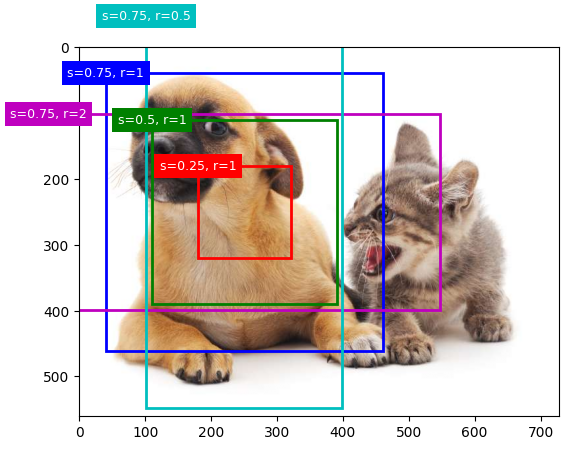

In [13]:
import matplotlib.patches as patches

scale = torch.tensor([w, h, w, h])

fig, ax = plt.subplots()
ax.imshow(img.permute(1, 2, 0))

show_bboxes(ax, boxes[250, 250, :, :] * scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

plt.show()